In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
standing_df = pd.read_csv('data/results/league_standings.csv')
standing_df.head()

,season,league,team,points,wins,draws,losses,goals_for,goals_against,goal_diff,played,position
0,2008/2009,Belgium Jupiler League,RSC Anderlecht,77,24,5,5,75,30,45,34,1
1,2008/2009,Belgium Jupiler League,Standard de Liège,77,24,5,5,66,26,40,34,2
2,2008/2009,Belgium Jupiler League,KAA Gent,59,17,8,9,67,42,25,34,3
3,2008/2009,Belgium Jupiler League,Club Brugge KV,59,18,5,11,59,50,9,34,4
4,2008/2009,Belgium Jupiler League,SV Zulte-Waregem,55,16,7,11,55,36,19,34,5


In [8]:
epl_15_16 = standing_df[standing_df['season'] == '2015/2016'][standing_df['league'] == 'England Premier League']

fig = go.Figure(data=[go.Table(
    header=dict(
        values=['Pos', 'Team', 'P', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts'],
        fill_color='#1a1a2e',
        font=dict(color='white', size=12),
        align='center'
    ),
    cells=dict(
        values=[epl_15_16[col] for col in ['position', 'team', 'played', 'wins', 'draws', 'losses', 'goals_for', 'goals_against', 'goal_diff', 'points']],
        fill_color=[['#f2f2f2' if i % 2 == 0 else 'white' for i in range(len(epl_15_16))]],
        align='center'
    )
)])

fig.update_layout(title='2015/2016 EPL Standings')
fig.show()

/var/folders/pp/9q27z0251bz7mk8h4tmcwh6h0000gn/T/ipykernel_58652/3797793769.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [4]:
home_adv_df = pd.read_csv('data/results/home_advantage.csv')
home_adv_df.head()

,league,season,avg_home_goals,avg_away_goals,home_advantage,win_percent,draw_percent,loss_percent
0,Netherlands Eredivisie,2010/2011,1.944444,1.281046,0.663399,0.522876,0.232026,0.245098
1,Switzerland Super League,2009/2010,1.994444,1.333333,0.661111,0.550000,0.161111,0.288889
2,Belgium Jupiler League,2011/2012,1.754167,1.125000,0.629167,0.495833,0.270833,0.233333
3,England Premier League,2009/2010,1.697368,1.073684,0.623684,0.507895,0.252632,0.239474
4,Poland Ekstraklasa,2010/2011,1.504167,0.904167,0.600000,0.516667,0.250000,0.233333


In [26]:
home_adv_df.sort_values('home_advantage', ascending=False).tail(10)

,league,season,avg_home_goals,avg_away_goals,home_advantage,win_percent,draw_percent,loss_percent
78,Scotland Premier League,2010/2011,1.381579,1.179825,0.201754,0.412281,0.214912,0.372807
79,Germany 1. Bundesliga,2009/2010,1.513072,1.316993,0.196078,0.408497,0.281046,0.310458
80,Belgium Jupiler League,2012/2013,1.562500,1.366667,0.195833,0.425000,0.245833,0.329167
81,Poland Ekstraklasa,2015/2016,1.420833,1.225000,0.195833,0.379167,0.308333,0.312500
82,Poland Ekstraklasa,2012/2013,1.341667,1.150000,0.191667,0.404167,0.262500,0.333333
83,Portugal Liga ZON Sagres,2010/2011,1.312500,1.120833,0.191667,0.420833,0.275000,0.304167
84,Portugal Liga ZON Sagres,2008/2009,1.233333,1.066667,0.166667,0.445833,0.266667,0.287500
85,Switzerland Super League,2010/2011,1.572222,1.411111,0.161111,0.400000,0.283333,0.316667
86,Scotland Premier League,2015/2016,1.504386,1.346491,0.157895,0.407895,0.228070,0.364035
87,Scotland Premier League,2011/2012,1.381579,1.254386,0.127193,0.394737,0.250000,0.355263


In [39]:
print('Number of league seasons:',
      home_adv_df.shape[0])

Number of league seasons: 88


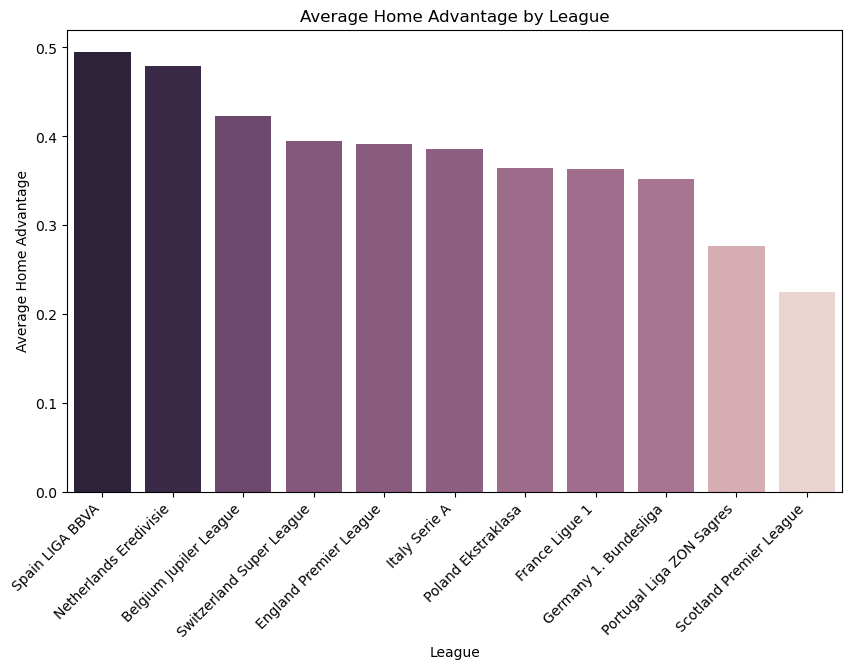

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(data = home_adv_df.groupby('league')['home_advantage'].mean().sort_values(ascending=False).reset_index(),
            x = 'league',
            y  = 'home_advantage',
            hue = 'home_advantage')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('League')
plt.ylabel('Average Home Advantage')
plt.title('Average Home Advantage by League')
plt.gca().get_legend().remove()
plt.show()

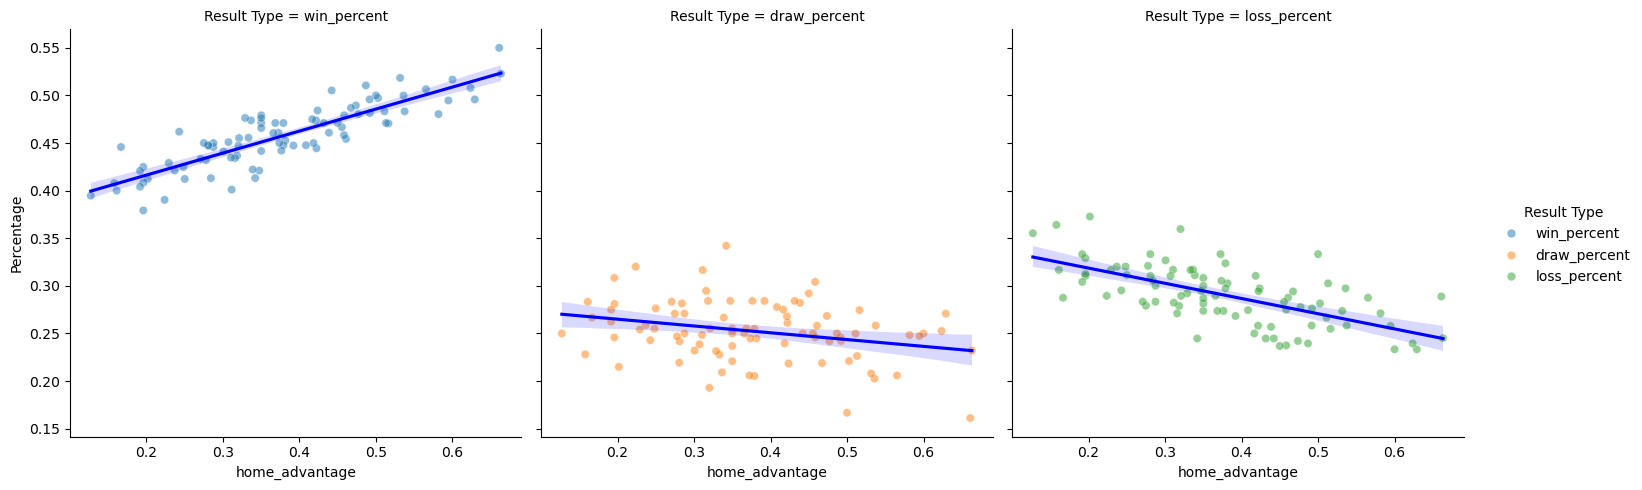

In [64]:
df_long = home_adv_df.melt(id_vars = ['home_advantage'],
                           value_vars = ['win_percent','draw_percent','loss_percent'],
                           var_name = 'Result Type',
                           value_name = 'Percentage')

fig = sns.relplot(data = df_long,
            x = 'home_advantage',
            y = 'Percentage',
            col = 'Result Type',
            hue = 'Result Type',
            #hue_order = ['Win','Draw','Loss'],
            kind = 'scatter',
            alpha = 0.5)
fig.map(sns.regplot, 'home_advantage', 'Percentage', scatter = False, color = 'blue')


plt.show()

In [5]:
running_pts_df = pd.read_csv('data/results/running_points_total.csv')
running_pts_df.head()

,team,season,date,rolling_5_game_points
0,Ruch Chorzów,2008/2009,2008-08-10 00:00:00,1
1,Ruch Chorzów,2008/2009,2008-08-16 00:00:00,4
2,Ruch Chorzów,2008/2009,2008-08-22 00:00:00,7
3,Ruch Chorzów,2008/2009,2008-08-30 00:00:00,7
4,Ruch Chorzów,2008/2009,2008-09-12 00:00:00,10


In [6]:
ssn_over_ssn_df = pd.read_csv('data/results/season_over_season.csv')
ssn_over_ssn_df.head()

,season,league,team,points,prev_season_points,points_change
0,2010/2011,Germany 1. Bundesliga,1. FC Kaiserslautern,46,NaN,NaN
1,2011/2012,Germany 1. Bundesliga,1. FC Kaiserslautern,23,46.0,-23.0
2,2008/2009,Germany 1. Bundesliga,1. FC Köln,39,NaN,NaN
3,2009/2010,Germany 1. Bundesliga,1. FC Köln,38,39.0,-1.0
4,2010/2011,Germany 1. Bundesliga,1. FC Köln,44,38.0,6.0
